In [2]:
import numpy as np
from folktables import ACSDataSource, ACSMobility, ACSEmployment
from matplotlib import pyplot as plt
import torch
from scipy import stats
from scipy.sparse.linalg import lobpcg
from scipy.linalg import eigh, eig
from sklearn.decomposition import PCA
import pandas as pd
from inFairness.distances import MahalanobisDistances, SquaredEuclideanDistance, LogisticRegSensitiveSubspace
from inFairness.fairalgo import SenSeI
from inFairness.auditor import SenSeIAuditor, SenSRAuditor
from tqdm.auto import tqdm
from utils import *

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import data

from ucimlrepo import fetch_ucirepo 

/Users/ceolson/miniforge3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/Users/ceolson/miniforge3/lib/python3.12/site-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = v

In [3]:
import importlib
import utils
importlib.reload(utils)
from utils import *

In [4]:
r = 3
p = 20
n = 120

In [9]:
for dataset in ["gaussian.1", "gaussian.5", "gaussian.20",
                "binomial.2", "binomial.5", "binomial.20",
                "ar.2", "ar.5", "ar.20",
                "ACSEmployment", "ACSMobility", "CreditCardDefault",
                "CDCDiabetes", "CommunityCrime"]:

    print(dataset)
    
    with open('transfer_20260303/numpy_saves_{}.npz'.format(dataset), 'rb') as f:
        loaded_data = np.load(f)
        S = loaded_data["S"]
        y = loaded_data["y"]
        Astar = loaded_data["Astar"]
        Kstar = loaded_data["Kstar"]
        X_train = loaded_data["X_train"]
        X_test = loaded_data["X_test"]
        Y_train = loaded_data["Y_train"]
        Y_test = loaded_data["Y_test"]
        
    with open(f"transfer_20260303/A_iterates_{dataset}.npy", "rb") as f:
        A_iterates = np.load(f)

    dists = pd.read_csv(f"transfer_20260303/dists_{dataset}.csv")

    input_metric_true = MahalanobisDistances()
    input_metric_true.fit(torch.Tensor(Astar @ Astar.T))
    
    output_metric = SquaredEuclideanDistance()
    output_metric.fit(num_dims=1)
    
    rho = 5
    eps = 0.1
    auditor_nsteps = 100
    auditor_lr = 0.01

    X_train_t = torch.Tensor(np.array(X_train))
    Y_train_t = torch.Tensor(np.array(Y_train))
    
    X_test_t = torch.Tensor(np.array(X_test))
    Y_test_t = torch.Tensor(np.array(Y_test))
    
    train_dataset = TrainDataset(X_train_t, Y_train_t)
    test_dataset = TrainDataset(X_test_t, Y_test_t)
    
    train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=8)
    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=8)

    loss_fn = torch.nn.functional.binary_cross_entropy


    for A in [A_iterates[i] for i in [199]]:
        network = NeuralNet(p)
        
        input_metric = MahalanobisDistances()
        input_metric.fit(torch.Tensor(A @ A.T))
    
        alg = SenSeI(network, input_metric, output_metric, loss_fn, rho, eps, auditor_nsteps, auditor_lr)
    
        optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
    
        alg.train()
    
        for epoch in range(200):
            for x, y in train_dl:
                optimizer.zero_grad()
                result = alg(x, torch.reshape(y, (-1, 1)))
                result.loss.backward()
                optimizer.step()
                
            batch_result = alg(X_train_t, torch.reshape(Y_train_t, (-1, 1)))
            # print(batch_result.loss)
            # if batch_result.loss < standard_loss:
            #     print("Stopping")
            #     break
    
        fair_loss = batch_result.loss
    
        auditor = SenSeIAuditor(input_metric, output_metric, 1000, auditor_lr)
        auditor_true = SenSeIAuditor(input_metric_true, output_metric, 1000, auditor_lr)
    
        audit = auditor.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)
        audit_true = auditor_true.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)
    
        ratios = []
        for X_1 in X_test_t:
            for X_2 in X_test_t:
                ratios.append((output_metric(network(X_1), network(X_2)) / input_metric(X_1, X_2)).detach().numpy())
        ratios = np.array(ratios)
        worst_ratio = np.max(ratios[~np.isnan(ratios)])
        mean_ratio = np.mean(ratios[~np.isnan(ratios)])
        std_ratio = np.std(ratios[~np.isnan(ratios)])
    
        ratios = []
        for X_1 in X_test_t:
            for X_2 in X_test_t:
                ratios.append((output_metric(network(X_1), network(X_2)) / input_metric_true(X_1, X_2)).detach().numpy())
        ratios = np.array(ratios)
        worst_ratio_true = np.max(ratios[~np.isnan(ratios)])
        mean_ratio_true = np.mean(ratios[~np.isnan(ratios)])
        std_ratio_true = np.std(ratios[~np.isnan(ratios)])
    
        print(fair_loss.detach().numpy(), audit, audit_true, worst_ratio, worst_ratio_true, 
              mean_ratio, mean_ratio_true, std_ratio, std_ratio_true)
    
        print(f"Ratios string: {mean_ratio:.4f} & {mean_ratio_true:.4f} & {worst_ratio:.4f} & {worst_ratio_true:.4f}")
        
        print(f"Audits string: {audit.lossratio_mean:.4f} & {audit_true.lossratio_mean:.4f} & {audit.lower_bound:.4f} & {audit_true.lower_bound:.4f}")

        print()

gaussian.1
0.699666 AuditorResponse(lossratio_mean=1.0023178, lossratio_std=0.022405135, lower_bound=0.9989535677577126, threshold=None, pval=None, confidence=None, is_model_fair=None) AuditorResponse(lossratio_mean=1.0005616, lossratio_std=0.030437332, lower_bound=0.9959913107317825, threshold=None, pval=None, confidence=None, is_model_fair=None) 16.544155 14.21604 0.019501042 0.019103834 0.20385851 0.17665233
Ratios string: 0.0195 & 0.0191 & 16.5442 & 14.2160
Audits string: 1.0023 & 1.0006 & 0.9990 & 0.9960

gaussian.5
0.6350032 AuditorResponse(lossratio_mean=1.0059047, lossratio_std=0.05202982, lower_bound=0.9980921940906322, threshold=None, pval=None, confidence=None, is_model_fair=None) AuditorResponse(lossratio_mean=0.99638456, lossratio_std=0.03803661, lower_bound=0.9906732153641363, threshold=None, pval=None, confidence=None, is_model_fair=None) 6.721957 5.555508 0.047590762 0.04757413 0.18747823 0.18759398
Ratios string: 0.0476 & 0.0476 & 6.7220 & 5.5555
Audits string: 1.0059 

In [11]:
result.y_pred

tensor([[0.4526],
        [0.3630],
        [0.3656],
        [0.6589],
        [0.4565],
        [0.7641],
        [0.6527],
        [0.4189]], grad_fn=<SigmoidBackward0>)

In [12]:
y

tensor([[0.5400],
        [0.1500],
        [0.1800],
        [0.9400],
        [0.3500],
        [1.0000],
        [0.8100],
        [0.2400]])

In [ ]:
for A in [A_iterates[i] for i in [199]]:
    network = NeuralNet(p)
    
    input_metric = MahalanobisDistances()
    input_metric.fit(torch.Tensor(A @ A.T))

    alg = SenSeI(network, input_metric, output_metric, loss_fn, rho, eps, auditor_nsteps, auditor_lr)

    optimizer = torch.optim.Adam(network.parameters(), lr=0.001)

    alg.train()

    for epoch in range(200):
        for x, y in train_dl:
            optimizer.zero_grad()
            result = alg(x, torch.reshape(y, (-1, 1)))
            result.loss.backward()
            optimizer.step()
            
        batch_result = alg(X_train_t, torch.reshape(Y_train_t, (-1, 1)))
        print(batch_result.loss)
        # if batch_result.loss < standard_loss:
        #     print("Stopping")
        #     break

    fair_loss = batch_result.loss

    auditor = SenSeIAuditor(input_metric, output_metric, 1000, auditor_lr)
    auditor_true = SenSeIAuditor(input_metric_true, output_metric, 1000, auditor_lr)

    audit = auditor.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)
    audit_true = auditor_true.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)

    ratios = []
    for X_1 in X_test_t:
        for X_2 in X_test_t:
            ratios.append((output_metric(network(X_1), network(X_2)) / input_metric(X_1, X_2)).detach().numpy())
    ratios = np.array(ratios)
    worst_ratio = np.max(ratios[~np.isnan(ratios)])
    mean_ratio = np.mean(ratios[~np.isnan(ratios)])
    std_ratio = np.std(ratios[~np.isnan(ratios)])

    ratios = []
    for X_1 in X_test_t:
        for X_2 in X_test_t:
            ratios.append((output_metric(network(X_1), network(X_2)) / input_metric_true(X_1, X_2)).detach().numpy())
    ratios = np.array(ratios)
    worst_ratio_true = np.max(ratios[~np.isnan(ratios)])
    mean_ratio_true = np.mean(ratios[~np.isnan(ratios)])
    std_ratio_true = np.std(ratios[~np.isnan(ratios)])

    print(fair_loss.detach().numpy(), audit, audit_true, worst_ratio, worst_ratio_true, 
          mean_ratio, mean_ratio_true, std_ratio, std_ratio_true)

    print(f"{mean_ratio:.4f} & {mean_ratio_true:.4f} & {worst_ratio:.4f} & {worst_ratio_true:.4f}")

In [272]:
print(f"{mean_ratio:.4f} & {mean_ratio_true:.4f} & {worst_ratio:.4f} & {worst_ratio_true:.4f}")

0.0113 & 0.0113 & 1.7709 & 1.7188


In [260]:
X_train_t = torch.Tensor(np.array(X_train))
Y_train_t = torch.Tensor(np.array(Y_train))

X_test_t = torch.Tensor(np.array(X_test))
Y_test_t = torch.Tensor(np.array(Y_test))

train_dataset = TrainDataset(X_train_t, Y_train_t)
test_dataset = TrainDataset(X_test_t, Y_test_t)

train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=8)
test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=8)

network_standard = NeuralNet(p)
optimizer = torch.optim.Adam(network_standard.parameters(), lr=1e-3)
loss_fn = torch.nn.functional.binary_cross_entropy

network_standard.train()

losses = []

for epoch in range(100):

    for x, y in train_dl:
        optimizer.zero_grad()
        y_pred = network_standard(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
    Y_pred = network_standard(X_train_t)
    loss = loss_fn(Y_pred, Y_train_t)
    losses.append(loss.detach().numpy())

standard_loss = loss

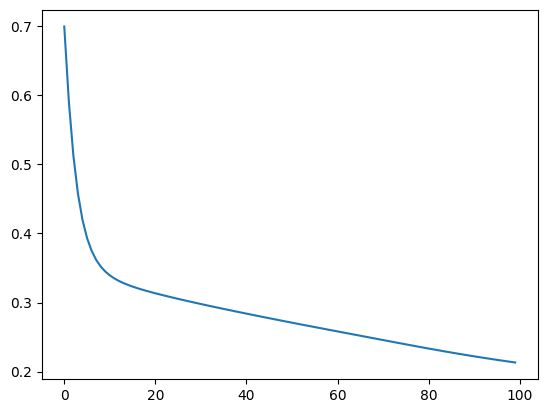

In [261]:
plt.plot(np.array(losses))

In [61]:
y_pred

tensor([[0.5711],
        [0.2840],
        [0.0208],
        [0.0071],
        [0.8870],
        [0.0184],
        [0.3494],
        [0.0094]], grad_fn=<SigmoidBackward0>)

In [62]:
total = 0
total_correct = 0
for x, y in test_dl:
    y_pred = network_standard(x)
    y_pred_bin = (y_pred > 0.5).to(int)
    num_correct = torch.sum((y_pred_bin == y).to(int))
    total_correct += num_correct
    total += len(y)
total_correct / total

tensor(0.8417)

In [63]:
np.mean(Y_test)

0.4666666666666667

In [64]:
standard_loss

tensor(0.1773, grad_fn=<BinaryCrossEntropyBackward0>)

In [5]:
Y_train.mean()

0    0.546808
dtype: float32